# Master IA Transilien

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor, Pool

try:
    import torch
    TASK_TYPE = 'GPU' if torch.cuda.is_available() else 'CPU'
except ImportError:
    TASK_TYPE = 'CPU'

print(f'Device : {TASK_TYPE}')
print(f'CatBoost {__import__("catboost").__version__} | sklearn {__import__("sklearn").__version__}')

Device : GPU
CatBoost 1.2.10 | sklearn 1.8.0


## 1. Chargement des données

In [29]:
X_train_raw = pd.read_csv('x_train_final.csv')
y_train_raw = pd.read_csv('y_train_final.csv')
X_test_raw  = pd.read_csv('x_test_final.csv')

print(f'x_train : {X_train_raw.shape}  |  x_test : {X_test_raw.shape}  |  y_train : {y_train_raw.shape}')
print(f'Target : {y_train_raw["p0q0"].describe().round(2).to_dict()}')

x_train : (667264, 12)  |  x_test : (20657, 11)  |  y_train : (667264, 2)
Target : {'count': 667264.0, 'mean': -0.16, 'std': 1.99, 'min': -160.0, '25%': -1.0, '50%': 0.0, '75%': 1.0, 'max': 15.0}


## 2. Feature Engineering

In [30]:
t0 = time.time()

le_gare = LabelEncoder()
le_gare.fit(pd.concat([X_train_raw['gare'], X_test_raw['gare']]).unique())

BACKWARD = ['p2q0', 'p3q0', 'p4q0']
LATERAL  = ['p0q2', 'p0q3', 'p0q4']
ALL_LAGS = BACKWARD + LATERAL

def build_features(df):
    df = df.copy()

    # Temporel
    df['date']         = pd.to_datetime(df['date'])
    df['jour_semaine'] = df['date'].dt.dayofweek
    df['semaine']      = df['date'].dt.isocalendar().week.astype(int)
    df['mois']         = df['date'].dt.month

    # Agrégats sur les lags
    df['mean_backward']  = df[BACKWARD].mean(axis=1)
    df['mean_lateral']   = df[LATERAL].mean(axis=1)
    df['mean_global']    = df[ALL_LAGS].mean(axis=1)
    df['std_backward']   = df[BACKWARD].std(axis=1)
    df['std_lateral']    = df[LATERAL].std(axis=1)
    df['trend']          = df['p2q0'] - df['p4q0']
    df['abs_trend']      = df['trend'].abs()
    df['max_lag']        = df[ALL_LAGS].max(axis=1)
    df['min_lag']        = df[ALL_LAGS].min(axis=1)
    df['range_backward'] = df[BACKWARD].max(axis=1) - df[BACKWARD].min(axis=1)
    df['range_all']      = df['max_lag'] - df['min_lag']
    df['n_late']         = (df[ALL_LAGS] > 0).sum(axis=1).astype(np.float32)
    df['n_very_late']    = (df[ALL_LAGS] > 3).sum(axis=1).astype(np.float32)
    df['p2q0_x_p0q2']   = df['p2q0'] * df['p0q2']
    df['weighted_lag']   = 0.5*df['p2q0'] + 0.3*df['p3q0'] + 0.2*df['p4q0']

    # Position dans le trajet
    df['arret_rank_pct'] = df.groupby(['train', 'date'])['arret'].rank(pct=True)
    df['arret_sq']       = df['arret'] ** 2

    # Encodage gare (CatBoost l'utilisera comme feature catégorielle)
    df['gare_enc'] = le_gare.transform(df['gare']).astype(str)

    # Gare précédente dans le trajet (pour graph features)
    _srt = df.sort_values(['train', 'date', 'arret'])
    _srt['prev_gare'] = _srt.groupby(['train', 'date'])['gare'].shift(1).fillna('__start__')
    df['prev_gare'] = _srt['prev_gare'].reindex(df.index)

    return df

X_all  = build_features(X_train_raw)
X_test = build_features(X_test_raw)
y_all  = y_train_raw['p0q0'].values.astype(np.float32)

print(f'Features construites ({time.time()-t0:.1f}s)')


Features construites (1.4s)


## 3. Split train/val + Target Encoding gare

In [31]:
import networkx as nx

idx_tr, idx_val = train_test_split(np.arange(len(X_all)), test_size=0.10, random_state=42)

fold_tr  = X_all.iloc[idx_tr].copy()
fold_val = X_all.iloc[idx_val].copy()
y_tr     = y_all[idx_tr]
y_val    = y_all[idx_val]

# ── Target encoding (train uniquement → pas de leakage) ─────────────────────
STAT_COLS_NAMES = ['gare_mean','gare_std','gare_median','gare_q10','gare_q25','gare_q75','gare_q90','gare_p_late']

stats = fold_tr.assign(p0q0=y_tr).groupby('gare')['p0q0'].agg(
    gare_mean   = 'mean',
    gare_std    = 'std',
    gare_median = 'median',
    gare_q10    = lambda x: x.quantile(0.10),
    gare_q25    = lambda x: x.quantile(0.25),
    gare_q75    = lambda x: x.quantile(0.75),
    gare_q90    = lambda x: x.quantile(0.90),
    gare_p_late = lambda x: (x > 0).mean(),
).reset_index()

fold_tr  = fold_tr.merge(stats, on='gare', how='left')
fold_val = fold_val.merge(stats, on='gare', how='left')
X_test   = X_test.merge(stats, on='gare', how='left')

for df in [fold_tr, fold_val, X_test]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']
    df['arret_x_gare_std']  = df['arret'] * df['gare_std']
    df['global_x_gare_p']   = df['mean_global'] * df['gare_p_late']

# ── Graph features ───────────────────────────────────────────────────────────
# Topologie réseau (train + test, sans target → pas de leakage)
_top = pd.concat([
    X_train_raw[['train','date','arret','gare']],
    X_test_raw [['train','date','arret','gare']]
]).sort_values(['train','date','arret'])

_eset = set()
for _, grp in _top.groupby(['train','date']):
    gs = grp['gare'].tolist()
    for i in range(len(gs) - 1):
        if gs[i] != gs[i+1]:
            _eset.add((gs[i], gs[i+1]))

G_top = nx.DiGraph(); G_top.add_edges_from(_eset)
_pr   = nx.pagerank(G_top, alpha=0.85)
_bc   = nx.betweenness_centrality(G_top, normalized=True)
_ind  = dict(G_top.in_degree())
_outd = dict(G_top.out_degree())

graph_topo = pd.DataFrame({
    'gare':             list(_pr),
    'gare_pagerank':    [_pr[g]          for g in _pr],
    'gare_betweenness': [_bc.get(g, 0)   for g in _pr],
    'gare_in_deg':      [_ind.get(g, 0)  for g in _pr],
    'gare_out_deg':     [_outd.get(g, 0) for g in _pr],
})
print(f'Graphe topologie : {G_top.number_of_nodes()} nœuds | {G_top.number_of_edges()} arêtes')

# Encodage de transition (fold train uniquement → pas de leakage)
def compute_trans_stats(df, y):
    tmp = df[['train','date','arret','gare','prev_gare']].copy()
    tmp['p0q0'] = y
    return (tmp[tmp['prev_gare'] != '__start__']
            .groupby(['prev_gare','gare'])['p0q0']
            .agg(transition_delay_mean='mean', transition_delay_std='std')
            .reset_index())

def apply_graph_feats(df, topo_df, trans_df, global_mean):
    drop = [c for c in ['gare_pagerank','gare_betweenness','gare_in_deg','gare_out_deg',
                        'transition_delay_mean','transition_delay_std'] if c in df.columns]
    df = df.drop(columns=drop)
    df = df.merge(topo_df, on='gare', how='left')
    df = df.merge(trans_df, on=['prev_gare','gare'], how='left')
    df['transition_delay_mean'] = df['transition_delay_mean'].fillna(global_mean)
    df['transition_delay_std']  = df['transition_delay_std'].fillna(0)
    return df

trans_stats = compute_trans_stats(fold_tr, y_tr)
_g_mean     = float(y_tr.mean())

fold_tr  = apply_graph_feats(fold_tr,  graph_topo, trans_stats, _g_mean)
fold_val = apply_graph_feats(fold_val, graph_topo, trans_stats, _g_mean)
X_test   = apply_graph_feats(X_test,   graph_topo, trans_stats, _g_mean)

# ── Features ─────────────────────────────────────────────────────────────────
FEATURES = [
    'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4',
    'mean_backward', 'mean_lateral', 'mean_global', 'std_backward', 'std_lateral',
    'trend', 'abs_trend', 'max_lag', 'min_lag', 'range_backward', 'range_all',
    'n_late', 'n_very_late', 'p2q0_x_p0q2', 'weighted_lag',
    'arret_rank_pct', 'arret_sq',
    'jour_semaine', 'semaine', 'mois',
    'gare_enc',
    'gare_mean', 'gare_std', 'gare_median', 'gare_q10', 'gare_q25', 'gare_q75', 'gare_q90', 'gare_p_late',
    'arret_x_gare_mean', 'arret_x_gare_std', 'global_x_gare_p',
    # Graph features
    'gare_pagerank', 'gare_betweenness', 'gare_in_deg', 'gare_out_deg',
    'transition_delay_mean', 'transition_delay_std',
]

train_pool = Pool(fold_tr[FEATURES].fillna(0),  y_tr,  cat_features=['gare_enc'])
val_pool   = Pool(fold_val[FEATURES].fillna(0), y_val, cat_features=['gare_enc'])

print(f'{len(FEATURES)} features | train={len(idx_tr):,} | val={len(idx_val):,}')


Graphe topologie : 84 nœuds | 1042 arêtes
45 features | train=600,537 | val=66,727


## 4. CatBoost

In [32]:
t0 = time.time()

cb = CatBoostRegressor(
    iterations=40000, learning_rate=0.03, depth=8,
    l2_leaf_reg=3, min_data_in_leaf=30,
    loss_function='MAE', eval_metric='MAE',
    task_type=TASK_TYPE, early_stopping_rounds=300,
    random_seed=42, verbose=200,
)
cb.fit(train_pool, eval_set=val_pool)

pred_val = cb.predict(fold_val[FEATURES].fillna(0))
mae_val  = mean_absolute_error(y_val, pred_val)
print(f'\nCatBoost MAE val : {mae_val:.4f} | best_iter={cb.best_iteration_}  ({time.time()-t0:.0f}s)')

Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.8948703	test: 0.8912386	best: 0.8912386 (0)	total: 31.4ms	remaining: 20m 54s
200:	learn: 0.7050206	test: 0.7021844	best: 0.7021844 (200)	total: 4.16s	remaining: 13m 44s
400:	learn: 0.6847908	test: 0.6828303	best: 0.6828303 (400)	total: 8.15s	remaining: 13m 24s
600:	learn: 0.6751921	test: 0.6737608	best: 0.6737608 (600)	total: 11.9s	remaining: 13m 3s
800:	learn: 0.6661007	test: 0.6653057	best: 0.6653057 (800)	total: 15.7s	remaining: 12m 47s
1000:	learn: 0.6605646	test: 0.6601942	best: 0.6601942 (1000)	total: 19.4s	remaining: 12m 37s
1200:	learn: 0.6544598	test: 0.6546602	best: 0.6546602 (1200)	total: 23.4s	remaining: 12m 36s
1400:	learn: 0.6505110	test: 0.6512737	best: 0.6512737 (1400)	total: 27.3s	remaining: 12m 31s
1600:	learn: 0.6474948	test: 0.6487272	best: 0.6487272 (1600)	total: 31.2s	remaining: 12m 29s
1800:	learn: 0.6457402	test: 0.6473657	best: 0.6473657 (1800)	total: 35.2s	remaining: 12m 26s
2000:	learn: 0.6430624	test: 0.6451530	best: 0.6451530 (2000)	total: 39.1s

## 5. Soumission finale — réentraînement sur 100% du train

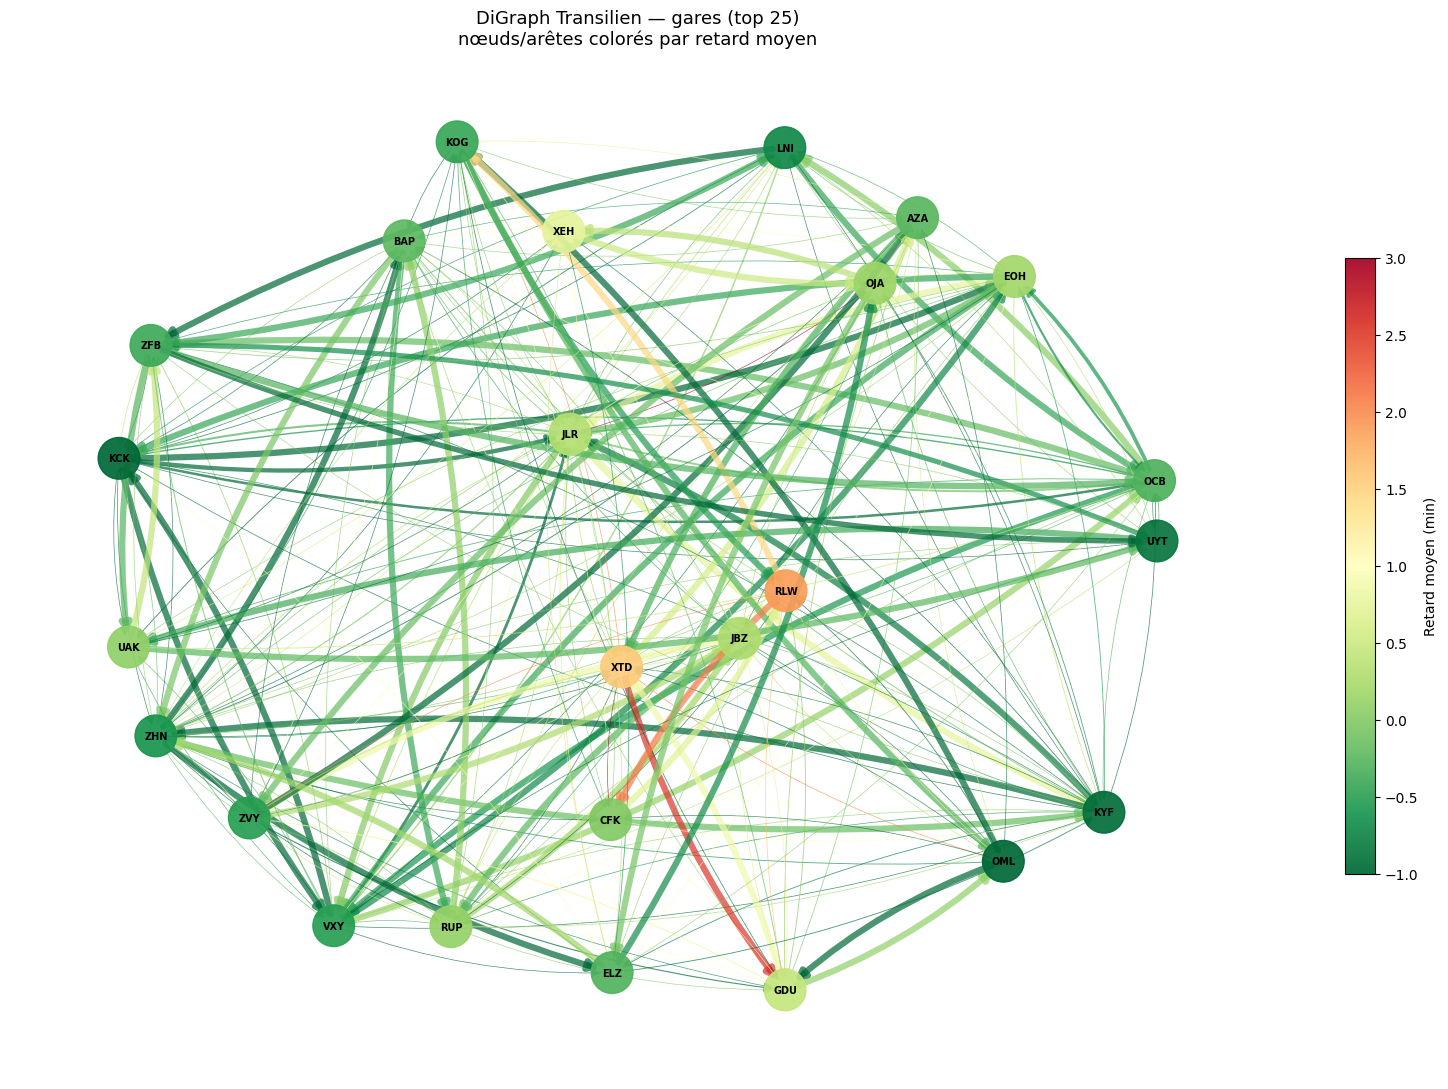

Graphe : 25 nœuds | 254 arêtes
Gares les plus en retard :
gare
RLW    1.895
XTD    1.562
XEH    0.726
GDU    0.441
JLR    0.303


In [33]:
import networkx as nx
from matplotlib import cm
import matplotlib.pyplot as plt

# ── Construction du DiGraph ────────────────────────────────────────────────────
df_g = X_train_raw[['train', 'date', 'arret', 'gare']].copy()
df_g['delay'] = y_train_raw['p0q0'].values

# Top 25 gares les plus fréquentes pour garder le graphe lisible
top_gares = df_g['gare'].value_counts().head(25).index.tolist()
df_g = df_g[df_g['gare'].isin(top_gares)]

# Arêtes dirigées : pour chaque trajet (train, date), relier les arrêts consécutifs
df_g = df_g.sort_values(['train', 'date', 'arret'])
edge_data = {}
for (train, date), grp in df_g.groupby(['train', 'date']):
    rows = grp[['gare', 'delay']].values.tolist()
    for i in range(len(rows) - 1):
        src, dst = rows[i][0], rows[i+1][0]
        if src != dst:
            edge_data.setdefault((src, dst), []).append(rows[i][1])

G = nx.DiGraph()
for (src, dst), delays in edge_data.items():
    G.add_edge(src, dst, weight=float(np.mean(delays)), count=len(delays))

# ── Visualisation ──────────────────────────────────────────────────────────────
node_delay = df_g.groupby('gare')['delay'].mean()
node_colors = [node_delay.get(n, 0) for n in G.nodes()]
edge_widths = [min(G[u][v]['count'] / 500, 4) + 0.5 for u, v in G.edges()]
edge_colors = [G[u][v]['weight'] for u, v in G.edges()]

pos = nx.spring_layout(G, seed=42, k=1.8, iterations=60)

fig, ax = plt.subplots(figsize=(16, 11))

nodes = nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=node_colors, cmap='RdYlGn_r', vmin=-1, vmax=3,
    node_size=900, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
edges = nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color=edge_colors, edge_cmap=cm.RdYlGn_r, edge_vmin=-1, edge_vmax=3,
    width=edge_widths, arrows=True, arrowsize=14,
    connectionstyle='arc3,rad=0.1', alpha=0.7)

plt.colorbar(nodes, ax=ax, label='Retard moyen (min)', shrink=0.6)
ax.set_title('DiGraph Transilien — gares (top 25)\nnœuds/arêtes colorés par retard moyen', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Graphe : {G.number_of_nodes()} nœuds | {G.number_of_edges()} arêtes')
print(f'Gares les plus en retard :')
print(node_delay.sort_values(ascending=False).head(5).round(3).to_string())


NN seed=42...
  best MAE val = 0.6711
NN seed=123...
  best MAE val = 0.6723
NN seed=777...
  best MAE val = 0.6728

NN ensemble MAE val : 0.6708  (407s)
Poids optimaux : CB=90%  NN=10%  MAE stack val=0.6270


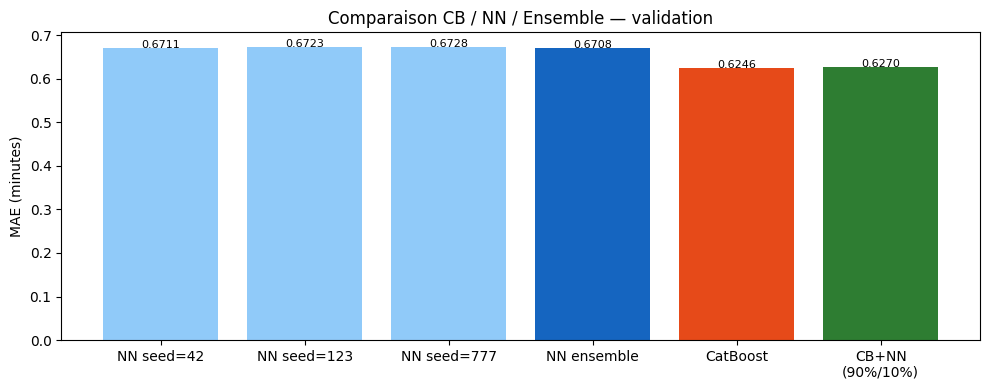

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_FEATS    = [f for f in FEATURES if f != 'gare_enc']
gare_col_idx = FEATURES.index('gare_enc')

def get_arrays(df_fold):
    mat = df_fold[FEATURES].fillna(0).values.astype(np.float32)
    return mat[:, [FEATURES.index(f) for f in NUM_FEATS]], mat[:, gare_col_idx].astype(int)

X_tr_num, gare_tr   = get_arrays(fold_tr)
X_val_num, gare_val = get_arrays(fold_val)

scaler   = RobustScaler()
X_tr_sc  = scaler.fit_transform(X_tr_num)
X_val_sc = scaler.transform(X_val_num)

def make_loader(gare, x, y=None, bs=4096, shuffle=True):
    t = [torch.LongTensor(gare), torch.FloatTensor(x)]
    if y is not None:
        t.append(torch.FloatTensor(y))
    return DataLoader(TensorDataset(*t), batch_size=bs, shuffle=shuffle,
                      pin_memory=True, num_workers=2, persistent_workers=True)

train_loader = make_loader(gare_tr,  X_tr_sc,  y_tr,  shuffle=True)
val_loader   = make_loader(gare_val, X_val_sc, y_val, shuffle=False)

N_GARES = le_gare.classes_.shape[0]
EMB_DIM = 32
N_NUM   = X_tr_sc.shape[1]

class DelayNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(N_GARES + 1, EMB_DIM, padding_idx=N_GARES)
        inp      = EMB_DIM + N_NUM
        self.net = nn.Sequential(
            nn.Linear(inp, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(256, 64),  nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(0.1),
            nn.Linear(64, 1),
        )
    def forward(self, g, x):
        return self.net(torch.cat([self.emb(g), x], dim=1)).squeeze(1)

def train_nn(seed, epochs=40):
    torch.manual_seed(seed); np.random.seed(seed)
    m     = DelayNet().to(DEVICE)
    opt   = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-3, epochs=epochs, steps_per_epoch=len(train_loader),
        pct_start=0.1, div_factor=25, final_div_factor=1e4,
    )
    crit  = nn.HuberLoss(delta=1.0)
    best_mae, best_state = float('inf'), None

    for epoch in range(1, epochs + 1):
        m.train()
        for g, x, y in train_loader:
            g, x, y = g.to(DEVICE), x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); crit(m(g, x), y).backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step(); sched.step()
        m.eval()
        with torch.no_grad():
            preds = np.concatenate([m(g.to(DEVICE), x.to(DEVICE)).cpu().numpy() for g, x, _ in val_loader])
        mae = mean_absolute_error(y_val, preds)
        if mae < best_mae:
            best_mae   = mae
            best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_state)
    m.eval()
    with torch.no_grad():
        val_p = np.concatenate([m(g.to(DEVICE), x.to(DEVICE)).cpu().numpy() for g, x, _ in val_loader])
    return m, val_p, best_mae

t0 = time.time()
NN_SEEDS = [42, 123, 777]
nn_models, nn_val_preds, nn_maes = [], [], []

for seed in NN_SEEDS:
    print(f'NN seed={seed}...')
    m, val_p, best = train_nn(seed)
    nn_models.append(m); nn_val_preds.append(val_p); nn_maes.append(best)
    print(f'  best MAE val = {best:.4f}')

pred_nn_val = np.mean(nn_val_preds, axis=0)
mae_nn = mean_absolute_error(y_val, pred_nn_val)
print(f'\nNN ensemble MAE val : {mae_nn:.4f}  ({time.time()-t0:.0f}s)')

# Poids optimaux CB vs NN par grille
best_w, best_mae_stack = 0.5, float('inf')
for w in np.arange(0.3, 0.95, 0.05):
    mae_s = mean_absolute_error(y_val, w * pred_val + (1-w) * pred_nn_val)
    if mae_s < best_mae_stack:
        best_mae_stack, best_w = mae_s, w
w_cb, w_nn = best_w, 1 - best_w
print(f'Poids optimaux : CB={w_cb:.0%}  NN={w_nn:.0%}  MAE stack val={best_mae_stack:.4f}')

# Graphique comparatif
labels = [f'NN seed={s}' for s in NN_SEEDS] + ['NN ensemble', 'CatBoost', f'CB+NN\n({w_cb:.0%}/{w_nn:.0%})']
values = nn_maes + [mae_nn, mae_val, best_mae_stack]
colors = ['#90CAF9']*3 + ['#1565C0', '#E64A19', '#2E7D32']
plt.figure(figsize=(10, 4))
bars = plt.bar(labels, values, color=colors)
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f'{v:.4f}', ha='center', fontsize=8)
plt.ylabel('MAE (minutes)'); plt.title('Comparaison CB / NN / Ensemble — validation')
plt.tight_layout(); plt.show()


In [36]:
t0 = time.time()

# Target encoding sur 100% des données d'entraînement
stats_full = X_all.assign(p0q0=y_all).groupby('gare')['p0q0'].agg(
    gare_mean   = 'mean',
    gare_std    = 'std',
    gare_median = 'median',
    gare_q10    = lambda x: x.quantile(0.10),
    gare_q25    = lambda x: x.quantile(0.25),
    gare_q75    = lambda x: x.quantile(0.75),
    gare_q90    = lambda x: x.quantile(0.90),
    gare_p_late = lambda x: (x > 0).mean(),
).reset_index()

X_all_f = X_all.drop(columns=STAT_COLS_NAMES, errors='ignore').merge(stats_full, on='gare', how='left')
X_te_f  = X_test.drop(columns=STAT_COLS_NAMES, errors='ignore').merge(stats_full, on='gare', how='left')

for df in [X_all_f, X_te_f]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']
    df['arret_x_gare_std']  = df['arret'] * df['gare_std']
    df['global_x_gare_p']   = df['mean_global'] * df['gare_p_late']

# Graph features (transition encodée sur 100% du train)
trans_stats_full = compute_trans_stats(X_all_f, y_all)
_g_mean_full     = float(y_all.mean())
X_all_f = apply_graph_feats(X_all_f, graph_topo, trans_stats_full, _g_mean_full)
X_te_f  = apply_graph_feats(X_te_f,  graph_topo, trans_stats_full, _g_mean_full)

full_pool = Pool(X_all_f[FEATURES].fillna(0), y_all, cat_features=['gare_enc'])

# ── CatBoost final ────────────────────────────────────────────────────────────
print(f'Réentraînement CatBoost sur 100% train (iter={cb.best_iteration_})...')
cb_f = CatBoostRegressor(
    iterations=cb.best_iteration_, learning_rate=0.03, depth=8,
    l2_leaf_reg=3, min_data_in_leaf=30,
    loss_function='MAE', task_type=TASK_TYPE,
    random_seed=42, verbose=0,
)
cb_f.fit(full_pool)
pred_test_cb = cb_f.predict(X_te_f[FEATURES].fillna(0))
print(f'  CatBoost done ({time.time()-t0:.0f}s)')

# ── Soumission CB seul (val=0.6246) ──────────────────────────────────────────
pred_final = np.clip(np.round(pred_test_cb).astype(int), -15, 15)
submission = pd.DataFrame({'Unnamed: 0': X_test_raw.index, 'p0q0': pred_final})
submission.to_csv('submission_cb_only.csv', index=False)

print(f'\nsubmission_cb_only.csv sauvegardé ({time.time()-t0:.0f}s)')
print(f'Distribution : {submission["p0q0"].describe().round(2).to_dict()}')


Réentraînement CatBoost sur 100% train (iter=26272)...


Default metric period is 5 because MAE is/are not implemented for GPU


  CatBoost done (508s)

submission_cb_only.csv sauvegardé (508s)
Distribution : {'count': 20657.0, 'mean': -0.11, 'std': 0.91, 'min': -15.0, '25%': -1.0, '50%': 0.0, '75%': 0.0, 'max': 4.0}
